# Main design

In [27]:
import qiskit_metal
qiskit_metal.about()


Qiskit Metal        0.8.1

Basic
____________________________________
 Python              3.11.15 (main, May  4 2026, 21:17:00) [MSC v.1944 64 bit (AMD64)]
 Platform            Windows AMD64
 Installation path   C:\Users\DELL\chip-design\metal-flow\quantum-metal\src\qiskit_metal

Packages
____________________________________
 Numpy               1.26.4
 Qutip               5.3.0

Rendering
____________________________________
 Matplotlib          3.11.0

GUI
____________________________________
 PySide6 version     6.11.1
 Qt version          6.11.1
 SIP version         Not installed

IBM Quantum Team


'\nQiskit Metal        0.8.1\n\nBasic\n____________________________________\n Python              3.11.15 (main, May  4 2026, 21:17:00) [MSC v.1944 64 bit (AMD64)]\n Platform            Windows AMD64\n Installation path   C:\\Users\\DELL\\chip-design\\metal-flow\\quantum-metal\\src\\qiskit_metal\n\nPackages\n____________________________________\n Numpy               1.26.4\n Qutip               5.3.0\n\nRendering\n____________________________________\n Matplotlib          3.11.0\n\nGUI\n____________________________________\n PySide6 version     6.11.1\n Qt version          6.11.1\n SIP version         Not installed\n\nIBM Quantum Team'

In [28]:
# Cell 1 — Imports + design skeleton
from qiskit_metal import designs, draw, MetalGUI, Dict
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

design = designs.DesignPlanar()
design.overwrite_enabled = True

design.chips.main.size['size_x'] = '11mm'
design.chips.main.size['size_y'] = '11mm'


In [ ]:
# Cell 2 (updated) — Q0–Q3 unchanged (TransmonPocket, 3 pads each fits the 4-corner limit).
# Q4 rebuilt as TransmonPocket6 with 5 angularly-placed connection pads.

from qiskit_metal.qlibrary.qubits.transmon_pocket_6 import TransmonPocket6


arm = "2 mm"


pad_opts = Dict(pad_width='50um', pad_height='30um', pad_gap='30um')

q0 = TransmonPocket6(design, 'Q0', options=Dict(
    pos_x=f'-{arm}', pos_y=f'{arm}', orientation=90, pad_width='425um', pocket_height='650um',
    connection_pads=Dict(
        to_Q4  =Dict(loc_W=-1, loc_H=-1, **pad_opts),
        to_Q2  =Dict(loc_W=-1, loc_H=+1, **pad_opts),
        readout=Dict(loc_W=+1, loc_H=+1, **pad_opts),
    )))


q1 = TransmonPocket6(design, 'Q1', options=Dict(
    pos_x=f'{arm}', pos_y=f'{arm}',orientation=-90, pad_width='425um', pocket_height='650um',
    connection_pads=Dict(
        readout=Dict(loc_W=-1, loc_H=+1, **pad_opts),
        to_Q3  =Dict(loc_W=+1, loc_H=+1, **pad_opts),
        to_Q4  =Dict(loc_W=+1, loc_H=-1, **pad_opts),
    )))

q2 = TransmonPocket6(design, 'Q2', options=Dict(
    pos_x=f'-{arm}', pos_y=f'-{arm}',orientation=-90, pad_width='425um', pocket_height='650um',
    connection_pads=Dict(
        readout=Dict(loc_W=+1, loc_H=-1, **pad_opts),
        to_Q0  =Dict(loc_W=-1, loc_H=-1, **pad_opts),
        to_Q4  =Dict(loc_W=-1, loc_H=+1, **pad_opts),
    )))

q3 = TransmonPocket6(design, 'Q3', options=Dict(
    pos_x=f'{arm}', pos_y=f'-{arm}',orientation=90, pad_width='425um', pocket_height='650um',
    connection_pads=Dict(
        readout=Dict(loc_W=-1, loc_H=-1, **pad_opts),
        to_Q1  =Dict(loc_W=+1, loc_H=-1, **pad_opts),
        to_Q4  =Dict(loc_W=+1, loc_H=+1, **pad_opts),
    )))

# TransmonPocket6: connection_pads placed by angle (connector_location, degrees, CCW from +x).
# connector_type='0' = claw connector (matches TransmonPocket's pin style for routing).
q4 = TransmonPocket6(design, 'Q4', options=Dict(
    pos_x='0mm', pos_y='0mm', orientation=0, pad_width='425um', pocket_width='650um', pocket_height='650um',
    connection_pads=Dict(
        to_Q0  = Dict(loc_W=-1, loc_H=+1, **pad_opts),
        to_Q1  = Dict(loc_W=+1, loc_H=+1, **pad_opts),
        to_Q2  = Dict(loc_W=-1, loc_H=-1, **pad_opts),
        to_Q3  = Dict(loc_W=+1, loc_H=-1, **pad_opts),
        readout= Dict(loc_W=+0, loc_H=+1, **pad_opts),
    )))

# NOTE: TransmonPocket6's exact option schema (key names for connector_location/
# connector_type) has shifted slightly between quantum-metal releases. If this
# throws a KeyError on rebuild, run:
# TransmonPocket6.get_template_options(design)
# and match the keys shown there.

In [30]:
# Cell 4 (updated) — direct qubit-qubit couplers, now meandered instead of straight.
to_q4_meander_common = Dict(trace_width='10um', trace_gap='6um', fillet='69um',
                       meander=Dict(spacing='200um'),
                       lead=Dict(start_straight='600um', end_straight='0um'))




c02_jogsS = Dict()
c02_jogsS[0] = ["R", "300um"]

c02_jogsE = Dict()
c02_jogsE[0] = ["L", "300um"]

c02_meander_opts = Dict(
    advanced= Dict(avoid_collision= "true"),
    meander=Dict(spacing= "300um", asymmetry="-100um"),
    snap="true",
    lead= Dict(
        start_straight= "0.2mm",
        end_straight= "0.2mm",
        start_jogged_extension= c02_jogsS,
        end_jogged_extension= c02_jogsE,
    ),
    fillet='99 um',
)


c02 = RouteMeander(design, 'C02', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q0', pin='to_Q2'),
                     end_pin=Dict(component='Q2', pin='to_Q0')),
    total_length='10mm', **c02_meander_opts))




c13_jogsS = Dict()
c13_jogsS[0] = ["L", "300um"]

c13_jogsE = Dict()
c13_jogsE[0] = ["R", "300um"]

c13_meander_opts = Dict(
    advanced= Dict(avoid_collision= "true"),
    meander=Dict(spacing= "300um", asymmetry="100um"),
    snap="true",
    lead= Dict(
        start_straight= "0.2mm",
        end_straight= "0.2mm",
        start_jogged_extension= c13_jogsS,
        end_jogged_extension= c13_jogsE,
    ),
    fillet='99 um',
)


c13 = RouteMeander(design, 'C13', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q1', pin='to_Q3'),
                     end_pin=Dict(component='Q3', pin='to_Q1')),
    total_length='10mm', **c13_meander_opts))

c04 = RouteMeander(design, 'C04', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q0', pin='to_Q4'),
                     end_pin=Dict(component='Q4', pin='to_Q0')),
    total_length='10mm', asymmetry='0um', **to_q4_meander_common))

c41 = RouteMeander(design, 'C41', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q1', pin='to_Q4'),
                     end_pin=Dict(component='Q4', pin='to_Q1')),
    total_length='10mm', asymmetry='0um', **to_q4_meander_common))

c24 = RouteMeander(design, 'C24', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q2', pin='to_Q4'),
                     end_pin=Dict(component='Q4', pin='to_Q2')),
    total_length='10mm', asymmetry='0um', **to_q4_meander_common))

c43 = RouteMeander(design, 'C43', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q3', pin='to_Q4'),
                     end_pin=Dict(component='Q4', pin='to_Q3')),
    total_length='10mm', asymmetry='0um', **to_q4_meander_common))

# If you get a "total_length too short for meander" error, bump total_length up —
# it must exceed the straight-line pin-to-pin distance plus the lead lengths.

In [31]:
# Cell 5 (updated) — Launchpads (corrected orientation) + feedline built from
# LaunchpadWirebond -> CoupledLineTee -> CoupledLineTee -> LaunchpadWirebond.
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee

lp_opts = Dict(trace_width='10um', trace_gap='6um', lead_length='30um')

# Top pads face south (270deg) into the chip; bottom pads face north (90deg) into the chip.
tl0_in  = LaunchpadWirebond(design, 'TL_0_IN',  options=Dict(pos_x='-5mm', pos_y='5mm',  orientation='270', **lp_opts))
tl0_out = LaunchpadWirebond(design, 'TL_0_OUT', options=Dict(pos_x='-5mm', pos_y='-5mm', orientation='90',  **lp_opts))
tl1_in  = LaunchpadWirebond(design, 'TL_1_IN',  options=Dict(pos_x='5mm',  pos_y='5mm',  orientation='270', **lp_opts))
tl1_out = LaunchpadWirebond(design, 'TL_1_OUT', options=Dict(pos_x='5mm',  pos_y='-5mm', orientation='90',  **lp_opts))

tee_opts = Dict(prime_width='10um', prime_gap='6um',
                 second_width='10um', second_gap='6um',
                 coupling_space='4um', coupling_length='200um', fillet='49um')

# Left side: prime line runs vertically -> rotate tee 90deg so second_end points east (toward Q0/Q2, at x=-3).
clt_q0 = CoupledLineTee(design, 'CLT_Q0', options=Dict(pos_x='-5mm', pos_y='3mm',  orientation='90',  mirror=False, **tee_opts))
clt_q2 = CoupledLineTee(design, 'CLT_Q2', options=Dict(pos_x='-5mm', pos_y='-3mm', orientation='90',  mirror=False, **tee_opts))

# Right side: rotate tee -90deg so second_end points west (toward Q1/Q3, at x=3).
clt_q1 = CoupledLineTee(design, 'CLT_Q1', options=Dict(pos_x='5mm', pos_y='3mm',  orientation='270', mirror=False, **tee_opts))
clt_q3 = CoupledLineTee(design, 'CLT_Q3', options=Dict(pos_x='5mm', pos_y='-3mm', orientation='270', mirror=False, **tee_opts))

# After gui.rebuild(), check that each tee's coupled stub (second_end) points at its
# qubit, not away from it — if it's mirrored, flip mirror=True and re-rebuild.

feed_opts = Dict(trace_width='10um', trace_gap='6um', fillet='0um')

tl0_seg1 = RouteStraight(design, 'TL_0_seg1', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='TL_0_IN', pin='tie'),
                     end_pin=Dict(component='CLT_Q0', pin='prime_end')), **feed_opts))
tl0_seg2 = RouteStraight(design, 'TL_0_seg2', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='CLT_Q0', pin='prime_start'),
                     end_pin=Dict(component='CLT_Q2', pin='prime_end')), **feed_opts))
tl0_seg3 = RouteStraight(design, 'TL_0_seg3', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='CLT_Q2', pin='prime_start'),
                     end_pin=Dict(component='TL_0_OUT', pin='tie')), **feed_opts))

tl1_seg1 = RouteStraight(design, 'TL_1_seg1', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='TL_1_IN', pin='tie'),
                     end_pin=Dict(component='CLT_Q1', pin='prime_start')), **feed_opts))
tl1_seg2 = RouteStraight(design, 'TL_1_seg2', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='CLT_Q1', pin='prime_end'),
                     end_pin=Dict(component='CLT_Q3', pin='prime_start')), **feed_opts))
tl1_seg3 = RouteStraight(design, 'TL_1_seg3', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='CLT_Q3', pin='prime_end'),
                     end_pin=Dict(component='TL_1_OUT', pin='tie')), **feed_opts))

In [32]:
# Cell 6 (updated) — Resonators R0-R3: CoupledLineTee.second_end -> qubit.readout (meandered).
# R4: Q4's own 5th pad, left as an open (unconnected) resonator per our earlier assumption
# that the diagram doesn't show a feedline for Q4.

res_opts = Dict(trace_width='10um', trace_gap='6um', fillet='99um',
                 lead=Dict(start_straight='60um', end_straight='60um'))

r0 = RouteMeander(design, 'R0', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q0', pin='readout'),
                     end_pin=Dict(component='CLT_Q0', pin='second_end')),
    total_length='22mm', meander=Dict(spacing='200um', asymmetry='-700um'), **res_opts))

r1 = RouteMeander(design, 'R1', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q1', pin='readout'),
                     end_pin=Dict(component='CLT_Q1', pin='second_end')),
    total_length='22mm', meander=Dict(spacing='200um', asymmetry='700um'), **res_opts))

r2 = RouteMeander(design, 'R2', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q2', pin='readout'),
                     end_pin=Dict(component='CLT_Q2', pin='second_end')),
    total_length='22mm', meander=Dict(spacing='200um', asymmetry='700um'), **res_opts))

r3 = RouteMeander(design, 'R3', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q3', pin='readout'),
                     end_pin=Dict(component='CLT_Q3', pin='second_end')),
    total_length='22mm', meander=Dict(spacing='200um', asymmetry='-700um'), **res_opts))


r4_lp_opts = Dict(trace_width='10um', trace_gap='6um', lead_length='30um')

r4_lp = LaunchpadWirebond(design, 'r4_lp', options=Dict(pos_x='0mm',  pos_y='5mm', orientation='-90',  **r4_lp_opts))


r4 = RouteMeander(design, 'R4', options=Dict(
    pin_inputs=Dict(start_pin=Dict(component='Q4', pin='readout'),
                     end_pin=Dict(component='r4_lp', pin='tie')),
    total_length='22mm', trace_width='10um', trace_gap='6um', fillet='99um',
                 lead=Dict(start_straight='1500um', end_straight='0um')))

['Q0', 'Q1', 'Q2', 'Q3', 'Q4', 'C02', 'C13', 'C04', 'C41', 'C24', 'C43', 'TL_0_IN', 'TL_0_OUT', 'TL_1_IN', 'TL_1_OUT', 'CLT_Q0', 'CLT_Q2', 'CLT_Q1', 'CLT_Q3', 'TL_0_seg1', 'TL_0_seg2', 'TL_0_seg3', 'TL_1_seg1', 'TL_1_seg2', 'TL_1_seg3', 'R0', 'R1', 'R2', 'R3', 'r4_lp', 'R4']


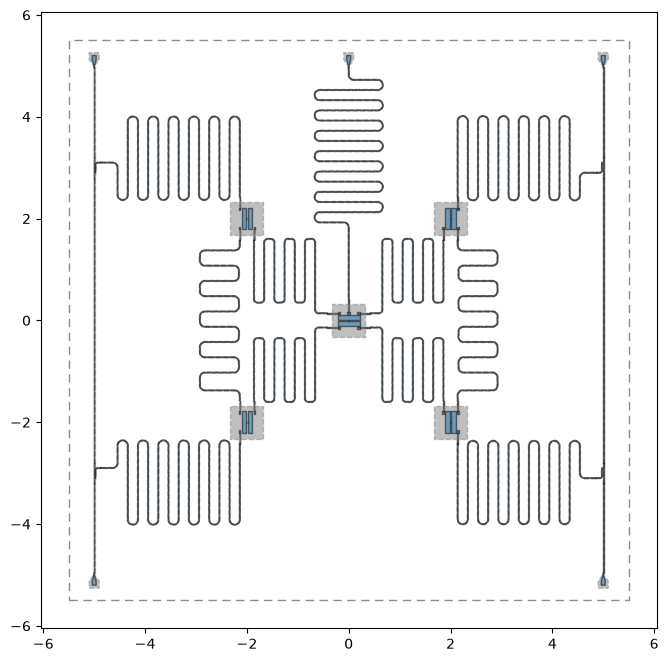

In [33]:
%matplotlib inline
from qiskit_metal import view
print(design.components.keys())
view(design)


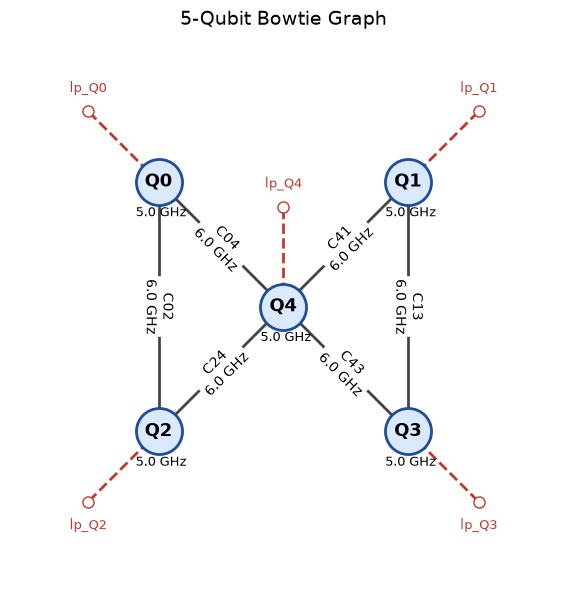

In [34]:
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# ---------- Graph: bowtie (two triangles sharing centre vertex C) ----------
G = nx.Graph()
G.add_nodes_from(["Q0", "Q2", "Q4", "Q1", "Q3"])

# (u, v, edge_label)
bowtie_edges = [
    ("Q0", "Q2", "C02"), ("Q2", "Q4", "C24"), ("Q0", "Q4", "C04"),   # left triangle
    ("Q4", "Q1", "C41"), ("Q1", "Q3", "C13"), ("Q4", "Q3", "C43"),   # right triangle
]
for u, v, lab in bowtie_edges:
    G.add_edge(u, v, label=lab)

# ---------- Dangling (unconnected) edges: one per vertex ----------
# Stored on the graph as node attributes; direction is a vector pointing away from the bowtie
stubs = {
    "Q0": ((-1,  1), "lp_Q0"),
    "Q2": ((-1, -1), "lp_Q2"),
    "Q4": (( 0,  1), "lp_Q4"),
    "Q1": (( 1,  1), "lp_Q1"),
    "Q3": (( 1, -1), "lp_Q3"),
}
for n, (direction, lab) in stubs.items():
    G.nodes[n]["stub_dir"] = direction
    G.nodes[n]["stub_label"] = lab

# ---------- Sublabels (fill these in; blank = reserved space) ----------
node_sublabels = {
                "Q0": "5.0 GHz",
                "Q2": "5.0 GHz",
                "Q4": "5.0 GHz",
                "Q1": "5.0 GHz",
                "Q3": "5.0 GHz",
                }
edge_sublabels = {("Q0", "Q2"): "6.0 GHz",
                  ("Q2", "Q4"): "6.0 GHz",
                  ("Q0", "Q4"): "6.0 GHz",
                  ("Q4", "Q1"): "6.0 GHz",
                  ("Q1", "Q3"): "6.0 GHz", 
                  ("Q4", "Q3"): "6.0 GHz"}
stub_sublabels = {n: "" for n in G.nodes}

# ---------- Layout ----------
pos = {"Q0": (-1, 1), "Q2": (-1, -1), "Q4": (0, 0), "Q1": (1, 1), "Q3": (1, -1)}

fig, ax = plt.subplots(figsize=(9, 6))

# Vertices and edges
nx.draw_networkx_edges(G, pos, ax=ax, width=2, edge_color="#444")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1100,
                       node_color="#dbe9ff", edgecolors="#1f4e99", linewidths=2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=13, font_weight="bold")

# Vertex sublabels (below each node)
for n, (x, y) in pos.items():
    ax.text(x + 0.02, y - 0.20, node_sublabels[n] or " ", ha="center", va="top",
            fontsize=9, color="black")

# Edge labels + sublabel slot on a second line
edge_text = {(u, v): f"{lab}\n{edge_sublabels[(u, v)] or ' '}"
             for u, v, lab in bowtie_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_text, ax=ax, font_size=10,
                             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=1.0))

# Dangling edges (dashed, open end, labelled)
stub_len = 0.8
pad = 0.12
for n, (x, y) in pos.items():
    d = np.array(G.nodes[n]["stub_dir"], dtype=float)
    d /= np.linalg.norm(d)
    x2, y2 = x + stub_len * d[0], y + stub_len * d[1]
    ax.plot([x, x2], [y, y2], ls="--", lw=2, color="#c0392b", zorder=1)
    ax.plot(x2, y2, marker="o", ms=8, mfc="white", mec="#c0392b", zorder=2)  # open end
    lab, sub = G.nodes[n]["stub_label"], stub_sublabels[n] or " "
    if d[1] >= 0:   # stub points up -> text above the circle, label line nearest the circle
        txt, va, ty = f"{sub}\n{lab}", "bottom", y2 + pad
    else:           # stub points down -> text below the circle, label line nearest the circle
        txt, va, ty = f"{lab}\n{sub}", "top", y2 - pad
    ax.text(x2, ty, txt, ha="center", va=va, fontsize=9, color="#c0392b")

ax.set_title("5-Qubit Bowtie Graph", fontsize=14)
ax.set_aspect("equal")
ax.margins(0.2)
ax.axis("off")
plt.tight_layout()

## Nominal frequency and $\alpha$ calculations using LOM 

In [124]:
def edit_and_print_qubit_properties(design, qubit_name):

    print("-"*50)
    print(f"Capacitive tuninig {qubit_name}")
    print("-"*50)
    print(f"pad_width = {design.components[qubit_name].options.pad_width}\npad_height = {design.components[qubit_name].options.pad_height}\npad_gap = {design.components[qubit_name].options.pad_gap}")
    print("-"*50)

    for pin in design.components[qubit_name].pin_names:
        design.components[qubit_name].options.connection_pads[pin].pad_width = '150 um'
        design.components[qubit_name].options.connection_pads[pin].pad_gap = '20 um'
        print(f"For pin {pin}")
        print(f"    pad_width = {design.components[qubit_name].options.connection_pads[pin].pad_width}")
        print(f"    pad_height = {design.components[qubit_name].options.connection_pads[pin].pad_height}")
        print(f"    pad_gap = {design.components[qubit_name].options.connection_pads[pin].pad_gap}")
        print("-"*50)

    design.rebuild()
    
    return None

In [ ]:
from qiskit_metal.analyses import LOManalysis

lom = LOManalysis(design, 'q3d')

qubit_name = 'Q0'

sweep_setup = Dict(design = design,
                        # Only simulate q0 and define its open terminations to extract exact capacitance matrix
                        run_args_dict = Dict(components=[design.components[qubit_name].name] , open_terminations=[(design.components[qubit_name].name, pad) for pad in design.components[qubit_name].pins.keys()], box_plus_buffer=True),
                        # LOM physics constraints (Josephson Junction Inductance & Capacitance)
                        lom_setup = Dict(junctions=Dict(Lj=10, Cj=2), freq_readout=[7.0], freq_bus=[6.0, 6.2]),
                        # Ansys Q3D Iterative solver properties
                        lom_sim_setup = Dict(name = f'{qubit_name}_setup', 
                                             reuse_selected_design = True, 
                                             reuse_setup = True,
                                             freq_ghz = 5.0,
                                             save_fields = True, 
                                             enabled = True, 
                                             max_passes = 35, 
                                             min_passes = 2, 
                                             min_converged_passes = 2, 
                                             percent_error = 0.5, 
                                             percent_refinement = 30, 
                                             auto_increase_solution_order = True, 
                                             solution_order = 'Highest', 
                                             solver_type = 'Iterative',
                                             ))



print(sweep_setup)

pad_widths = [width for width in range(400, 600, 25)]
pad_heights = [height for height in range(50, 200, 15)]
pad_gaps = [gap for gap in range(10, 55, 5)]

pin_pad_widths  = [width for width in range(30, 200, 20)]
pin_pad_heights = [height for height in range(20, 50, 5)]
pin_pad_gaps = [gap for gap in range(5, 50, 5)]

Ljs = [Lj for Lj in range(5, 26, 1)]

lom.setup = sweep_setup.lom_setup
lom.sim.setup = sweep_setup.lom_sim_setup

data_list = []
from itertools import product

# Define the parameter grids
qubit_grid = product(pad_widths, pad_heights, pad_gaps)
pin_grid = product(pin_pad_widths, pin_pad_heights, pin_pad_gaps)

# Combine both grids to iterate through every configuration
for q_params, p_params in product(qubit_grid, pin_grid):
    w, h, g = q_params
    pw, ph, pg = p_params
    
    # Update main qubit pads
    qubit = design.components[qubit_name]
    qubit.options.pad_width = f"{w}um"
    qubit.options.pad_height = f"{h}um"
    qubit.options.pad_gap = f"{g}um"
    
    # Update all connection pads
    for pin in qubit.pin_names:
        qubit.options.connection_pads[pin].pad_width = f"{pw}um"
        qubit.options.connection_pads[pin].pad_height = f"{ph}um"
        qubit.options.connection_pads[pin].pad_gap = f"{pg}um"
        
        design.rebuild()
        result_dict = {"pad_width_um":w, "pad_height_um":h, "pad_gap_um":g, "pin_pad_width_um":pw, "pin_pad_height_um":ph, "pin_pad_gap_um":pg}
        print("="*10+"Iteration"+"="*10)
        print(result_dict)

        # lom.sim.design.rebuild()

        # lom.sim.run(name=qubit_name+'_capacitive', **sweep_setup.run_args_dict)

        # for inductance in Ljs:
        #     lom.setup.junctions.Lj = inductance
        #     lom.run_lom()
        #     result_dict.update({"input_Lj":inductance})
        #     result_dict.update(lom.lumped_oscillator)
        #     data_list.append(result_dict)

{'design': <qiskit_metal.designs.design_planar.DesignPlanar object at 0x0000019D78E47490>, 'run_args_dict': {'components': ['Q0'], 'open_terminations': [('Q0', 'to_Q4'), ('Q0', 'to_Q2'), ('Q0', 'readout')], 'box_plus_buffer': True}, 'lom_setup': {'junctions': {'Lj': 10, 'Cj': 2}, 'freq_readout': [7.0], 'freq_bus': [6.0, 6.2]}, 'lom_sim_setup': {'name': 'Q0_setup', 'reuse_selected_design': True, 'reuse_setup': True, 'freq_ghz': 5.0, 'save_fields': True, 'enabled': True, 'max_passes': 35, 'min_passes': 2, 'min_converged_passes': 2, 'percent_error': 0.5, 'percent_refinement': 30, 'auto_increase_solution_order': True, 'solution_order': 'Highest', 'solver_type': 'Iterative'}}
==========Iteration==========
{'pad_width_um': 400, 'pad_height_um': 50, 'pad_gap_um': 10, 'pin_pad_width_um': 30, 'pin_pad_height_um': 20, 'pin_pad_gap_um': [5, 10, 15, 20, 25, 30, 35, 40, 45]}
==========Iteration==========
{'pad_width_um': 400, 'pad_height_um': 50, 'pad_gap_um': 10, 'pin_pad_width_um': 30, 'pin_pad_h

KeyboardInterrupt: 

In [123]:
lom.setup = Dict(junctions=Dict(Lj=30, Cj=2), freq_readout=[6.0], freq_bus=[5.0, 5.2])
lom.run_lom()

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.892314 [GHz]
EC 786.808943 [MHz]
EJ 5.444324 [GHz]
alpha -1103.712326 [MHz]
dispersion 484126.204338 [KHz]
Lq 30.000000 [nH]
Cq 24.618719 [fF]
T1 308746.557144 [us]

**Coupling Properties**

tCqbus1 -0.041620 [fF]
gbus1_in_MHz -0.925450 [MHz]
χ_bus1 -0.000790 [MHz]
1/T1bus1 0.337965 [Hz]
T1bus1 470920.962136 [us]

tCqbus2 0.009843 [fF]
gbus2_in_MHz 0.180005 [MHz]
χ_bus2 -0.000549 [MHz]
1/T1bus2 0.136683 [Hz]
T1bus2 1164409.253901 [us]

tCqbus3 0.014684 [fF]
gbus3_in_MHz 0.281249 [MHz]
χ_bus3 -0.000404 [MHz]
1/T1bus3 0.040839 [Hz]
T1bus3 3897126.129070 [us]
Bus-Bus Couplings
gbus1_2 49.162421 [MHz]
gbus1_3 23.995136 [MHz]
gbus2_3 84.580446 [MHz]


,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,χr MHz,gr MHz
1,5.278031,964.708299,5.444324,-1122.384371,859312.597992,"[-0.6998119307305722, 2.6980111596865033, -9.8...","[-0.0008352027164601276, 0.06943146378783618, ...",0.000835,0.699812
2,5.140897,898.241929,5.444324,-1131.801117,709462.56246,"[-0.8874386608844844, 3.4228104929193672, 2.47...","[-0.0010582590803545776, 0.18965679102793917, ...",0.001058,0.887439
3,5.053324,857.653099,5.444324,-1128.20261,623374.763639,"[-1.0363509541417992, 0.7407642348348012, -0.2...","[-0.0012558678222018636, 0.021588188860869197,...",0.001256,1.036351
4,4.973084,821.737867,5.444324,-1118.753309,550949.060026,"[-0.9515199112532373, -0.9069402396124601, 0.2...","[-0.0009381303305632117, -0.05970439670942639,...",0.000938,0.951520
5,4.946208,809.979523,5.444324,-1114.34277,528044.81273,"[-0.9345010367893947, -0.6325447837837095, 0.3...","[-0.0008699422159329091, -0.01420131947058246,...",0.000870,0.934501
6,4.922843,799.867633,5.444324,-1110.021613,508677.369226,"[-0.9330136397036612, -0.47706934299433346, 0....","[-0.0008383330917309397, -0.005521880115371746...",0.000838,0.933014
7,4.9053,792.342537,5.444324,-1106.486577,494465.713939,"[-0.9256495448588417, -0.041341482483847586, 0...","[-0.000804640495675564, -3.3293168148566876e-0...",0.000805,0.925650
8,4.892314,786.808943,5.444324,-1103.712326,484126.204338,"[-0.92544992856929, 0.1800051903450484, 0.2812...","[-0.0007895376367340548, -0.000549111984599899...",0.000790,0.925450


In [127]:
lom.lumped_oscillator

{'fQ': 4.892314007664319,
 'EC': 786.8089427978276,
 'EJ': 5.444323709512798,
 'alpha': -1103.7123257346082,
 'dispersion': 484126.20433799265,
 'gbus': array([-0.92544993,  0.18000519,  0.28124857]),
 'chi_in_MHz': array([-0.00078954, -0.00054911, -0.000404  ])}

In [46]:
lom.sim.close()

In [47]:
del lom